**Object Detection using YOLOv4**

Load the model and classes

In [ ]:
import requests
from os import path

classesFile = "coco.names"

# Download the coco.names file if it doesn't exist
if not path.exists(classesFile):
    print('Downloading coco.names...')
    # Official Darknet COCO names URL
    url = "https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names"
    r = requests.get(url)
    with open(classesFile, 'wb') as f:
        f.write(r.content)
    print('Download complete!')

Download complete!


In [ ]:
# Load names of classes.
classesFile = "coco.names"
classes = None
with open(classesFile, 'rt') as f:
    classes = f.read().rstrip('\n').split('\n')

# Give the configuration and weight files for the model and load the network using them.
modelConfiguration = "yolov4.cfg"
modelWeights = "yolov4.weights"

if(not path.exists(modelWeights)):

    url = "https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.weights"

    r = requests.get(url)

    print('Downloading YOLO v4 Model.......')

    with open(modelWeights, 'wb') as f:
        f.write(r.content)

    print('\nyolov4.weights Download complete!')


yolov4.weights Download complete!


In [ ]:
# Download config
!wget https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4.cfg

# Download weights (~245 MB)
!wget https://pjreddie.com/media/files/yolov4.weights

--2025-12-30 19:45:05--  https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4.cfg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12231 (12K) [text/plain]
Saving to: ‘yolov4.cfg’

yolov4.cfg          100%[===================>]  11.94K  --.-KB/s    in 0s      

2025-12-30 19:45:06 (117 MB/s) - ‘yolov4.cfg’ saved [12231/12231]

--2025-12-30 19:45:06--  https://pjreddie.com/media/files/yolov4.weights
Resolving pjreddie.com (pjreddie.com)... 172.67.185.199, 104.21.88.156, 2606:4700:3037::6815:589c, ...
Connecting to pjreddie.com (pjreddie.com)|172.67.185.199|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/yolov4.weights [following]
--2025-12-30 19:45:06--  https://data.pjr

In [ ]:
import cv2
net = cv2.dnn.readNetFromDarknet(modelConfiguration, modelWeights)

Process each frame

In [ ]:
def getOutputsNames(net):
    layersNames = net.getLayerNames()
    out_layers = net.getUnconnectedOutLayers()

    # Handle both OpenCV formats
    if len(out_layers.shape) == 2:
        return [layersNames[i[0] - 1] for i in out_layers]
    else:
        return [layersNames[i - 1] for i in out_layers]

The main loop

Inference using YOLOv4

Saving unnamed.png to unnamed (2).png
Uploaded image: unnamed (2).png


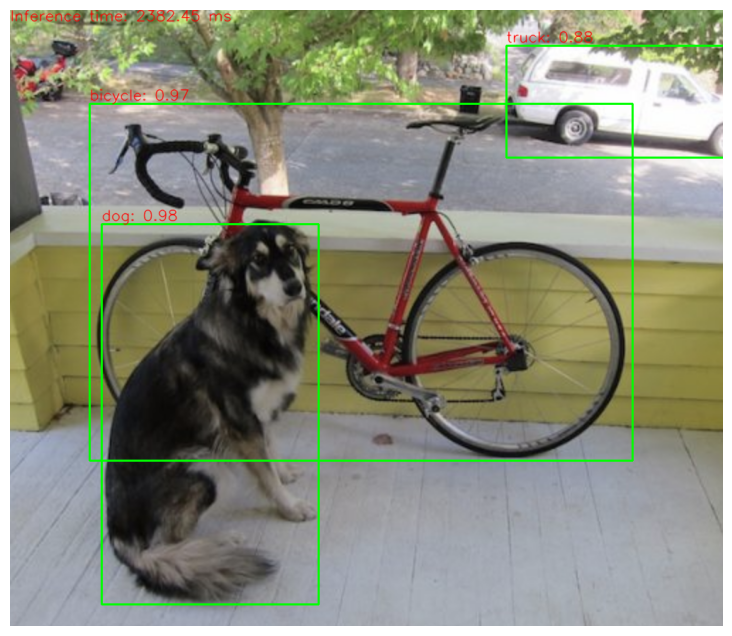

Inference time: 2382.45 ms


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Parameters
objectnessThreshold = 0.5
confThreshold = 0.5
nmsThreshold = 0.4
inpWidth = 416   # YOLO input width
inpHeight = 416  # YOLO input height
FONTFACE = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 0.7
THICKNESS = 1

# Load class names
classes = []
with open("coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

# Load YOLO model
net = cv2.dnn.readNetFromDarknet("yolov4.cfg", "yolov4.weights")

# Helper function to get output layer names
def getOutputsNames(net):
    layersNames = net.getLayerNames()
    out_layers = net.getUnconnectedOutLayers()
    if len(out_layers.shape) == 2:
        return [layersNames[i[0] - 1] for i in out_layers]
    else:
        return [layersNames[i - 1] for i in out_layers]

# Upload image
uploaded = files.upload()

# Get uploaded file name
imagePath = next(iter(uploaded))
print("Uploaded image:", imagePath)

# Read image
frame = cv2.imread(imagePath)
if frame is None:
    raise IOError("❌ Image not found or cannot be loaded.")

# Create a 4D blob
blob = cv2.dnn.blobFromImage(frame, 1/255, (inpWidth, inpHeight), [0,0,0], swapRB=True, crop=False)
net.setInput(blob)

# Forward pass
outs = net.forward(getOutputsNames(net))

# Process outputs
frameHeight, frameWidth = frame.shape[:2]
classIds, confidences, boxes = [], [], []

for out in outs:
    for detection in out:
        if detection[4] > objectnessThreshold:
            scores = detection[5:]
            classId = np.argmax(scores)
            confidence = scores[classId]
            if confidence > confThreshold:
                center_x = int(detection[0] * frameWidth)
                center_y = int(detection[1] * frameHeight)
                width = int(detection[2] * frameWidth)
                height = int(detection[3] * frameHeight)
                left = int(center_x - width / 2)
                top = int(center_y - height / 2)
                classIds.append(classId)
                confidences.append(float(confidence))
                boxes.append([left, top, width, height])

# Apply NMS
if len(boxes) > 0:
    indices = cv2.dnn.NMSBoxes(boxes, confidences, confThreshold, nmsThreshold)
    if len(indices) > 0:
        indices = indices.flatten()
        for i in indices:
            box = boxes[i]
            left, top, width, height = box
            cv2.rectangle(frame, (left, top), (left + width, top + height), (0, 255, 0), 2)
            label = f"{classes[classIds[i]]}: {confidences[i]:.2f}"
            cv2.putText(frame, label, (left, top - 5), FONTFACE, FONT_SCALE, (0, 0, 255), THICKNESS, cv2.LINE_AA)

# Inference time
t, _ = net.getPerfProfile()
label = f'Inference time: {t * 1000.0 / cv2.getTickFrequency():.2f} ms'
cv2.putText(frame, label, (0, 15), FONTFACE, FONT_SCALE, (0, 0, 255), THICKNESS, cv2.LINE_AA)

# Show image
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

print(label)